# Cuaderno 01: Análisis Exploratorio de Datos (EDA)


*1. Configuración del Entorno*

importacion de las librerías necesarias para la manipulación de datos y la creación de visualizaciones. Se establece un estilo unificado para mantener la coherencia visual en todo el reporte.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo para las visualizaciones
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

*2. Carga e Inspección Inicial de Datos*

Carga del conjunto de datos y revisión preliminar para entender su dimensionalidad y los tipos de datos disponibles.

In [2]:
print("Cargando el dataset...")
df = pd.read_csv('../data/RealEstate_California.csv')
# Inspección inicial
print(f"El dataset contiene {df.shape[0]} filas y {df.shape[1]} columnas.")
display(df.head())
display(df.info())

Cargando el dataset...
El dataset contiene 35389 filas y 39 columnas.


,Unnamed: 0,id,stateId,countyId,cityId,country,datePostedString,is_bankOwned,is_forAuction,event,...,parking,garageSpaces,hasGarage,levels,pool,spa,isNewConstruction,hasPetsAllowed,homeType,county
0,0,95717-2087851113,9,77,24895,USA,2021-01-13,0,0,Listed for sale,...,0,0.0,0,0,0,0,0,0,LOT,Placer County
1,1,94564-18496265,9,189,36958,USA,2021-07-12,0,0,Listed for sale,...,1,2.0,1,One Story,0,0,0,0,SINGLE_FAMILY,Contra Costa County
2,2,94564-18484475,9,190,36958,USA,2021-07-08,0,0,Listed for sale,...,1,2.0,1,One Story,0,0,0,0,SINGLE_FAMILY,Contra Costa County
3,3,94564-18494835,9,191,36958,USA,2021-07-07,0,0,Listed for sale,...,1,1.0,1,Two Story,0,1,0,0,SINGLE_FAMILY,Contra Costa County
4,4,94564-2069722747,9,192,36958,USA,2021-07-07,0,0,Listed for sale,...,0,0.0,0,0,0,0,0,0,LOT,Contra Costa County


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35389 entries, 0 to 35388
Data columns (total 39 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          35389 non-null  int64  
 1   id                  35389 non-null  object 
 2   stateId             35389 non-null  int64  
 3   countyId            35389 non-null  int64  
 4   cityId              35389 non-null  int64  
 5   country             35389 non-null  object 
 6   datePostedString    35386 non-null  object 
 7   is_bankOwned        35389 non-null  int64  
 8   is_forAuction       35389 non-null  int64  
 9   event               35100 non-null  object 
 10  time                35100 non-null  float64
 11  price               35389 non-null  float64
 12  pricePerSquareFoot  35389 non-null  float64
 13  city                35389 non-null  object 
 14  state               35389 non-null  object 
 15  yearBuilt           35389 non-null  int64  
 16  stre

None

*3. Limpieza Inicial (Data Wrangling)*

Eliminacion de columnas que actúan como identificadores únicos o variables redundantes (como `stateId` y `country`, dado que todas las propiedades están en California, EE. UU.). Estas variables no aportan capacidad predictiva y podrían generar ruido en el modelo. Además, se evalua la presencia de valores nulos.

In [3]:
# eliminacion de columnas redundantes o de identificadores
cols_to_drop = ['Unnamed: 0', 'id', 'stateId', 'country', 'datePostedString']
df_clean = df.drop(columns=cols_to_drop)

# Revisión de valores nulos
print("\nValores nulos por columna:")
nulos = df_clean.isnull().sum()
display(nulos[nulos > 0])


Valores nulos por columna:


event            289
time             289
streetAddress      1
zipcode           25
description      279
dtype: int64

*4. Análisis de la Variable Objetivo (`price`)*

Analisis de la distribución de la variable a predecir. Creacion de un histograma para observar el sesgo y un diagrama de caja (boxplot) para identificar valores atípicos (outliers). 

**Justificación técnica:** La detección de outliers es crítica porque modelos como la Regresión Lineal son altamente sensibles a valores extremos. Observaremos si es necesario aplicar un filtro temporal para evitar que propiedades de lujo extremo sesguen el análisis general.

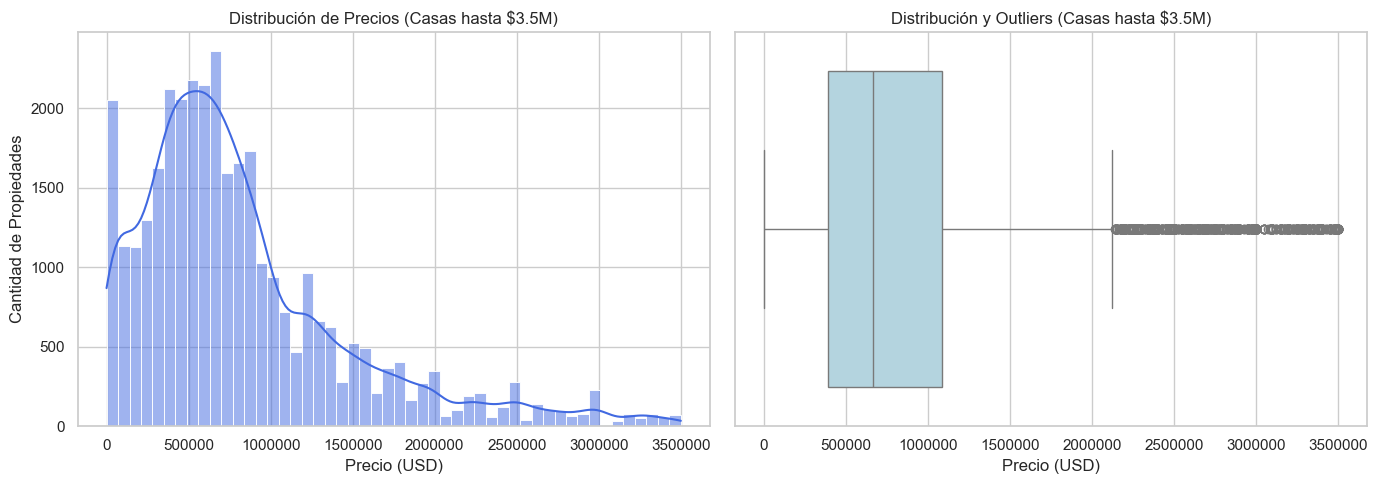

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Definimos un límite visual (ej. 3.5 millones) para hacer "zoom" en el mercado normal
limite_zoom = 3500000 
datos_zoom = df_clean[df_clean['price'] < limite_zoom]

# Gráfico 1: Histograma enfocado
sns.histplot(datos_zoom['price'], bins=50, kde=True, color='royalblue', ax=axes[0])
axes[0].set_title('Distribución de Precios (Casas hasta $3.5M)')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Cantidad de Propiedades')
# Esta línea APAGA la notación científica (el 1e7 molesto)
axes[0].ticklabel_format(style='plain', axis='x')

# Gráfico 2: Boxplot enfocado
sns.boxplot(x=datos_zoom['price'], color='lightblue', ax=axes[1])
axes[1].set_title('Distribución y Outliers (Casas hasta $3.5M)')
axes[1].set_xlabel('Precio (USD)')
# Apagamos la notación científica también aquí
axes[1].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

df_filtered = df_clean[df_clean['price'] < 5000000]

1. **Histograma (Izquierda):** La distribución presenta un claro **sesgo positivo (hacia la derecha)**. Esto indica que la gran mayoría de las propiedades se concentran en el segmento de precios más bajos a medios (probablemente entre los $500,000 y $1.5 millones), mientras que la cantidad de propiedades disminuye drásticamente a medida que el precio aumenta. 
2. **Diagrama de Caja / Boxplot (Derecha):** La "caja" central nos muestra dónde se encuentra el 50% de nuestro mercado objetivo (el Rango Intercuartílico). La línea dentro de la caja representa el precio **mediano**. Además, los puntos negros que se extienden en la parte superior nos indican que, incluso dentro de este segmento filtrado, existen "valores atípicos estadísticos" o propiedades premium que escapan a la norma de su zona.

**Conclusión para el Modelado:** Este comportamiento sesgado es típico en bienes raíces. Dado que la mayoría de nuestros datos están agrupados en los rangos de precios bajos y medios, nuestros modelos (como Random Forest) serán mucho más precisos valorando casas "estándar" que intentando predecir el precio exacto de mansiones atípicas.

*5. Visualización de Patrones Geográficos*

El mercado inmobiliario es altamente dependiente de la ubicación. Aprovechando las coordenadas de latitud y longitud, proyectamos las propiedades para identificar zonas de alta plusvalía.

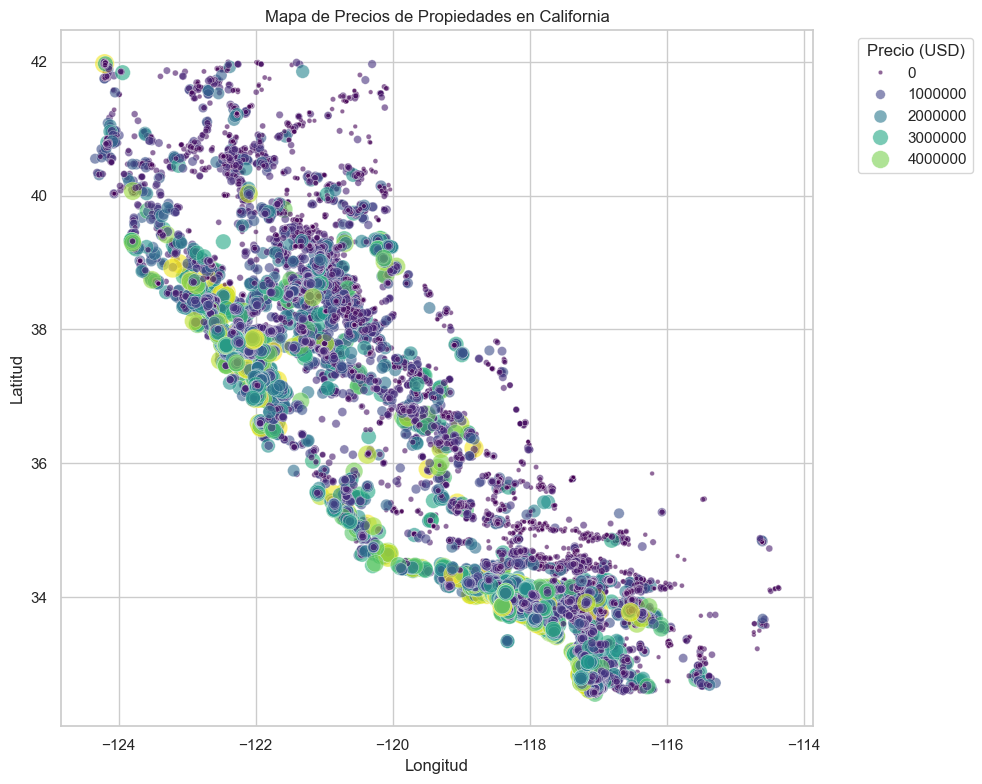

In [5]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_filtered, 
    x='longitude', 
    y='latitude', 
    hue='price', 
    palette='viridis', 
    size='price', 
    sizes=(10, 200), 
    alpha=0.6
)
plt.title('Mapa de Precios de Propiedades en California')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend(title='Precio (USD)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

*6. Correlación de Variables*

Para la selección de características (Feature Selection), se calculó la matriz de correlación de Pearson entre las variables numéricas. Esto permite identificar multicolinealidad (variables independientes muy correlacionadas entre sí) y descubrir cuáles atributos tienen la relación lineal más fuerte con el precio.

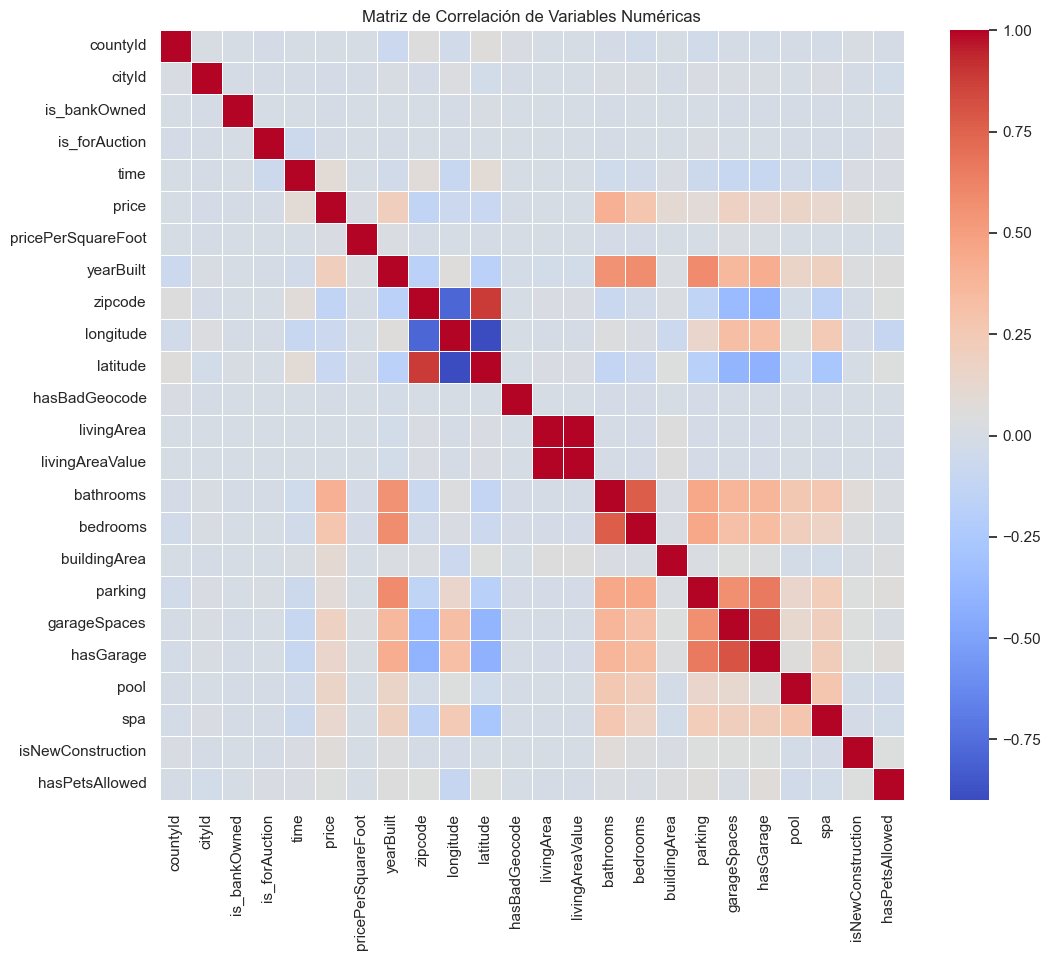

In [6]:
plt.figure(figsize=(12, 10))

# Filtramos solo las variables numéricas para la correlación
numeric_cols = df_filtered.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

# Creamos el mapa de calor (heatmap)
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

*7. Refinamiento Final y Feature Engineering Espacial (K-Means)*

En esta etapa realizamos los últimos ajustes de limpieza sobre los datos estructurados y aplicamos técnicas de Machine Learning no supervisado para extraer mayor valor de las coordenadas geográficas.

1. **Tratamiento de Nulos Restantes:** Depuramos registros sin código postal (crítico para identificar la zona) e imputamos las descripciones de texto faltantes. Para la variable de tiempo (`time`), utilizamos la **mediana** como método de imputación robusto ante valores atípicos.
2. **Impacto Directo en el Precio:** Filtramos la matriz de correlación para observar exclusivamente cómo cada variable numérica interactúa con nuestra variable objetivo (`price`), facilitando la posterior selección de características.
3. **Agrupación Geográfica (Clustering):** Extraemos la latitud y longitud para crear una nueva variable categórica (`geo_cluster`) que agrupa las propiedades en 5 macro-zonas territoriales.

**Justificación técnica (K-Means y Escalado):** La creación de clústeres espaciales ayuda a los modelos lineales a entender "barrios" o zonas de influencia que de otro modo requerirían el procesamiento complejo de coordenadas brutas. Antes de aplicar K-Means, es mandatorio utilizar `StandardScaler` para normalizar los datos, dado que este algoritmo se basa en el cálculo de distancias euclidianas y es altamente sensible a la diferencia de magnitudes en los ejes cartesianos.

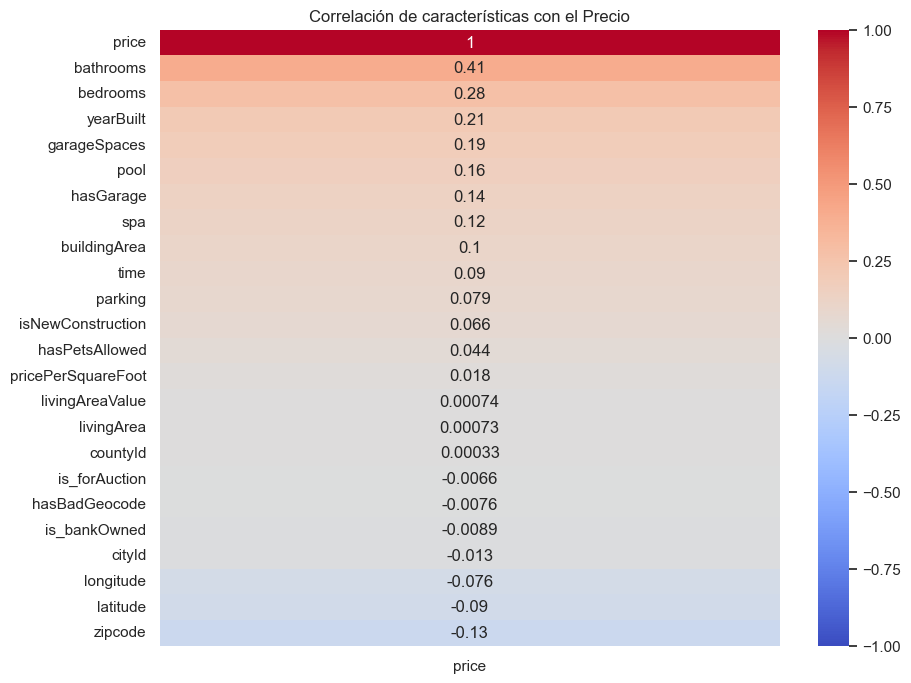

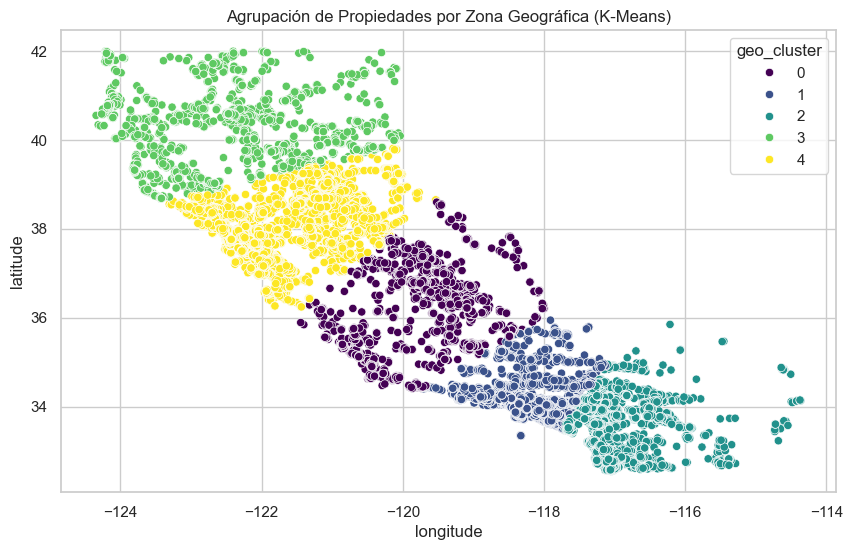

In [7]:
# importacion de las herramientas de machine learning y preprocesamiento necesarias
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# copia de los datos filtrados 
df_procesado = df_filtered.copy()

# eliminacion de las filas que no tienen codigo postal
df_procesado = df_procesado.dropna(subset=['zipcode'])

# se rellenan los valores nulos en columnas de texto con una categoria por defecto
columnas_texto = ['event', 'description', 'streetAddress']
df_procesado[columnas_texto] = df_procesado[columnas_texto].fillna('Desconocido')

# imputacion de los valores faltantes en la columna de tiempo usando la mediana
df_procesado['time'] = df_procesado['time'].fillna(df_procesado['time'].median())

# calculo de la matriz de correlacion para evaluar el impacto numerico en la variable objetivo
matriz_corr = df_procesado.corr(numeric_only=True)

# grafico de la matriz de correlacion enfocada en el precio
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr[['price']].sort_values(by='price', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de características con el Precio')
plt.show()

# se aislan las coordenadas para aplicar el algoritmo de agrupacion
coordenadas = df_procesado[['latitude', 'longitude']]

# normalizacion de la escala de los datos geograficos
scaler = StandardScaler()
coordenadas_escaladas = scaler.fit_transform(coordenadas)

# K-Means: para agrupar las propiedades en 5 zonas territoriales
kmeans = KMeans(n_clusters=5, random_state=42)
df_procesado['geo_cluster'] = kmeans.fit_predict(coordenadas_escaladas)

# visualización
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_procesado, x='longitude', y='latitude', hue='geo_cluster', palette='viridis')
plt.title('Agrupación de Propiedades por Zona Geográfica (K-Means)')
plt.show()

*8. Exportación de Datos Procesados*

Una vez finalizada la exploración y la limpieza inicial (eliminación de columnas irrelevantes, tratamiento de nulos básicos y filtrado de outliers), exportamos el DataFrame resultante a un nuevo archivo CSV. 

**Justificación técnica:** Esto asegura la persistencia de los datos limpios y permite que los siguientes cuadernos de la pipeline trabajen sobre una base de datos estandarizada, mejorando la eficiencia y reproducibilidad del proyecto.

In [8]:
# Definimos la ruta de guardado
ruta_guardado = '../data/RealEstate_California_Clean.csv'

# Guardamos el dataframe procesado
df_procesado.to_csv(ruta_guardado, index=False)

print(f"¡Éxito! El dataset limpio se ha guardado en: {ruta_guardado}")

¡Éxito! El dataset limpio se ha guardado en: ../data/RealEstate_California_Clean.csv
